In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json

In [10]:
# Load JSON
with open("../datasets/CLINC150/data_full.json") as f:
    data = json.load(f)

In [22]:
# Structure
data.keys()

dict_keys(['oos_val', 'val', 'train', 'oos_test', 'test', 'oos_train'])

### Dataset Structure
The CLINC150 dataset contains user queries and their corresponding intent labels.
The dataset is divided into train, validation, and test splits for machine learning tasks.

In [69]:
# Convert into DataFrames
train_df = pd.DataFrame(data['train'], columns=['text', 'intent'])
val_df = pd.DataFrame(data['val'], columns=['text', 'intent'])
test_df = pd.DataFrame(data['test'], columns=['text', 'intent'])

In [70]:
# Combine them
df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22500 entries, 0 to 22499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    22500 non-null  str  
 1   intent  22500 non-null  str  
dtypes: str(2)
memory usage: 351.7 KB


In [71]:
# Total Samples
len(df)

22500

### Number of Samples
The dataset contains a large number of conversational queries, making it suitable for intent classification experiments and NLP model training.

In [72]:
# Number of Intents
df['intent'].nunique()

150

In [73]:
# Intent names
df['intent'].unique()

<StringArray>
[           'translate',             'transfer',                'timer',
           'definition',      'meaning_of_life',     'insurance_change',
           'find_phone',         'travel_alert',          'pto_request',
 'improve_credit_score',
 ...
      'how_old_are_you',           'car_rental',           'jump_start',
      'meal_suggestion',               'recipe',               'income',
                'order',              'traffic',         'order_checks',
        'card_declined']
Length: 150, dtype: str

### Number of Intents & names
The dataset contains 150 unique intents covering multiple domains such as banking, travel, music, weather, utilities, and communication.

In [74]:
# Label distribution
intent_cnts = df['intent'].value_counts()
print(intent_cnts)

intent
translate          150
transfer           150
timer              150
definition         150
meaning_of_life    150
                  ... 
income             150
order              150
traffic            150
order_checks       150
card_declined      150
Name: count, Length: 150, dtype: int64


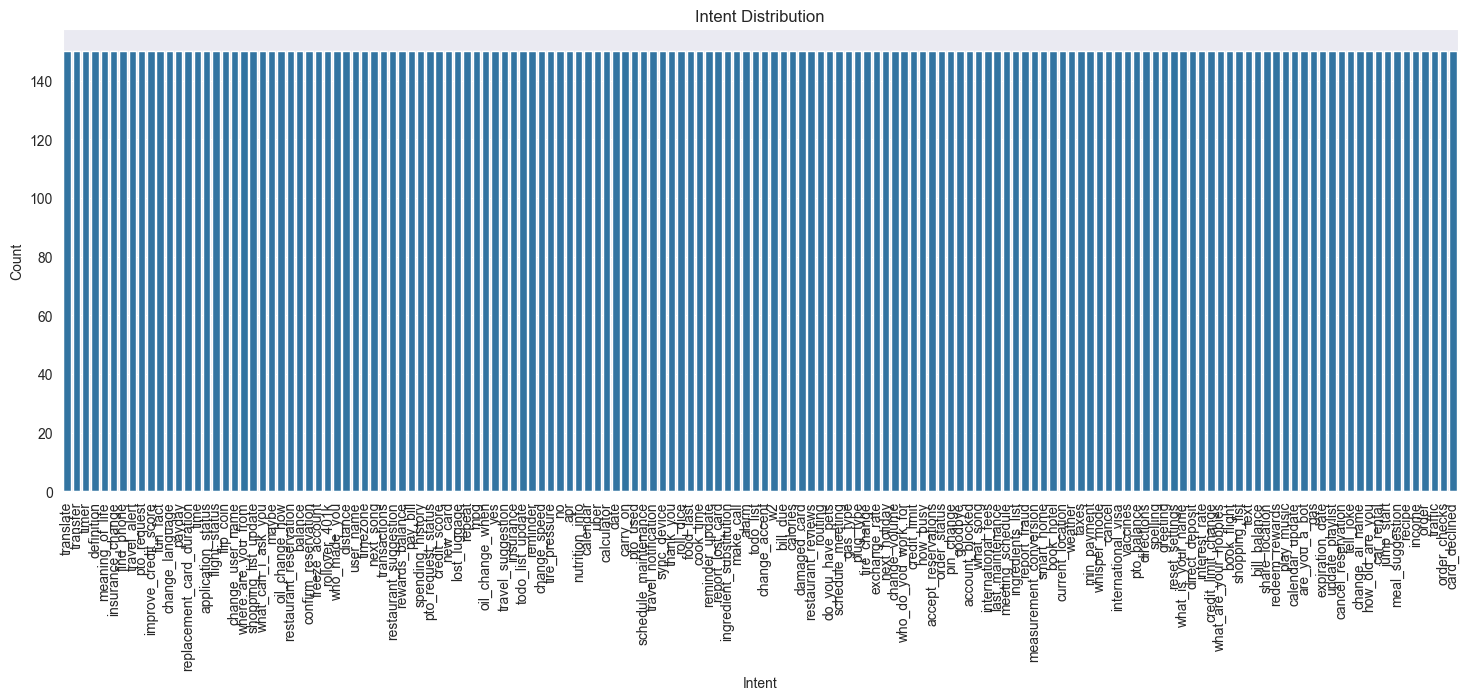

In [75]:
# Visualization
plt.figure(figsize=(18,6))
sns.barplot(x=intent_cnts.index, y=intent_cnts.values)
plt.xticks(rotation=90)
plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.show()

In [76]:
# Dataset Statistics
print(intent_cnts.describe())

count    150.0
mean     150.0
std        0.0
min      150.0
25%      150.0
50%      150.0
75%      150.0
max      150.0
Name: count, dtype: float64


### Label Distribution
The label distribution graph shows that almost all intents contain nearly the same number of samples.

**Observation:**
The dataset is highly balanced, which helps machine learning models learn fairly across all classes without bias toward specific intents.

In [77]:
# Average Query Length
df['query_length'] = df['text'].apply(lambda x: len(x.split()))
avg_length = df['query_length'].mean()
print(avg_length)

8.306933333333333


### Query Length Analysis
Most queries are short conversational sentences containing only a few words.

**Observation:**
The average query length is relatively small because the dataset represents real-world chatbot or virtual assistant interactions.

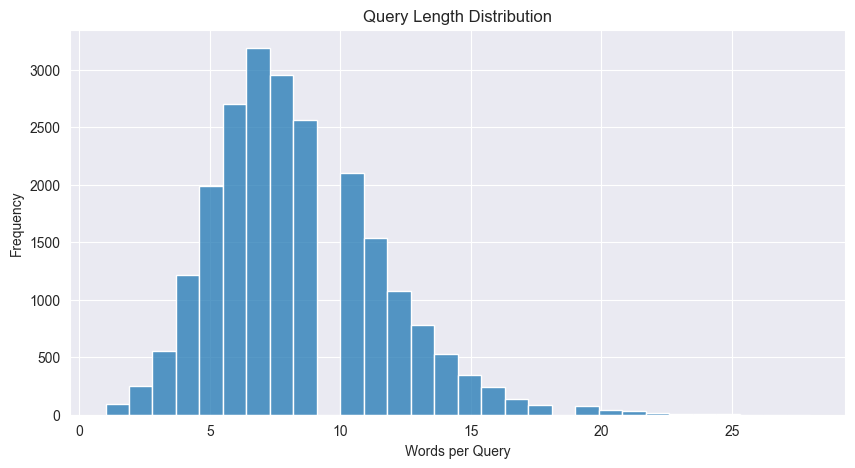

In [78]:
# Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['query_length'], bins=30)
plt.title("Query Length Distribution")
plt.xlabel("Words per Query")
plt.ylabel("Frequency")
plt.show()

### Query Length Distribution
The histogram shows that most queries fall within a small word range, while very long queries are rare.

**Observation:**
The dataset mainly consists of concise and direct user commands or questions.

In [79]:
# Duplicates Texts
dups = df[df.duplicated(subset=['text'])]
print(len(dups))
print(dups.head())

5
                           text              intent  query_length
16011  what is on my to do list            reminder             7
16794       turn up your volume       change_volume             4
17369             hey what's up            greeting             3
18599     where did you grow up  where_are_you_from             5
18938   what's your designation           user_name             3


### Duplicate Text Analysis
A small number of duplicate texts may exist in the dataset.

**Observation:**
Duplicate queries can occur because users may ask the same question in similar ways across different splits.

In [80]:
# Missing Values
print(df.isnull().sum())

text            0
intent          0
query_length    0
dtype: int64


### Missing Values
No missing values were found in either the text or intent columns.

**Observation:**
The dataset is clean and well-structured, requiring minimal preprocessing.

In [81]:
# Top frequent words
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])
word_cnts = np.asarray(X.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()
freq_df = pd.DataFrame({'words': words, 'counts': word_cnts})
freq_df = freq_df.sort_values(by='counts', ascending=False)
freq_df.head(20)

,words,counts
3667,need,1923
1043,card,1735
5305,tell,1472
3013,know,1272
1499,credit,1049
282,account,886
1039,car,826
3165,list,769
5752,want,766
3138,like,765


### Frequent Word Analysis
Frequently occurring words represent common conversational actions and topics such as account access, payments, music, travel, and reminders.

**Observation:**
The dataset vocabulary reflects real-world assistant interactions and domain-specific intent patterns.

### Semantic Overlap Between Intents
Some intents are semantically similar and may confuse machine learning models.
Examples:
- transfer vs exchange_rate
- play_music vs music_query
- travel_alert vs travel_notification
**Observation:**
Closely related intents share similar vocabulary and context, which may lead to classification ambiguity.

## Final Conclusion

The CLINC150 dataset is a balanced and clean intent classification dataset containing 150 intents and conversational user queries.
The dataset is suitable for NLP experiments, intent classification systems, chatbot research, and machine learning benchmarking.
Although the dataset is well-balanced, some intents overlap semantically, which may create challenges during model prediction.